Part 1: Import Libraries & Load Dataset

In [ ]:
# ==========================================
# SALES & DEMAND FORECASTING
# Future Interns - Task 1
# Author: Shashikant Jha
# ==========================================

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [ ]:
# Load Dataset
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

# Display first 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
print("Rows and Columns:", df.shape)

Rows and Columns: (9994, 21)


In [ ]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [ ]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


Part 2: Data Cleaning & Preparation

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
# Convert date columns into datetime format

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Check data types
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
df = df.dropna()

In [ ]:
print("Duplicate Rows Before:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicate Rows After:", df.duplicated().sum())

Duplicate Rows Before: 0
Duplicate Rows After: 0


In [ ]:
print(df.shape)

(9994, 21)


In [ ]:
df = df.sort_values(by='Order Date')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
7980,7981,CA-2014-103800,2014-01-03,2014-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
739,740,CA-2014-112326,2014-01-04,2014-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
740,741,CA-2014-112326,2014-01-04,2014-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
741,742,CA-2014-112326,2014-01-04,2014-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
1759,1760,CA-2014-141817,2014-01-05,2014-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [ ]:
df.reset_index(drop=True, inplace=True)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,7981,CA-2014-103800,2014-01-03,2014-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,740,CA-2014-112326,2014-01-04,2014-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
2,741,CA-2014-112326,2014-01-04,2014-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
3,742,CA-2014-112326,2014-01-04,2014-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
4,1760,CA-2014-141817,2014-01-05,2014-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [ ]:
print("Start Date :", df['Order Date'].min())
print("End Date   :", df['Order Date'].max())

Start Date : 2014-01-03 00:00:00
End Date   : 2017-12-30 00:00:00


In [ ]:
df['Sales'].describe()

,Sales
count,9994.000000
mean,229.858001
std,623.245101
min,0.444000
25%,17.280000
50%,54.490000
75%,209.940000
max,22638.480000


In [ ]:
monthly_sales = df.groupby('Order Date')['Sales'].sum().reset_index()

monthly_sales.head()

,Order Date,Sales
0,2014-01-03,16.448
1,2014-01-04,288.060
2,2014-01-05,19.536
3,2014-01-06,4407.100
4,2014-01-07,87.158


In [ ]:
monthly_sales = monthly_sales.set_index('Order Date')

monthly_sales = monthly_sales.resample('M').sum()

monthly_sales.head()

,Sales
Order Date,
2014-01-31,14236.895
2014-02-28,4519.892
2014-03-31,55691.009
2014-04-30,28295.345
2014-05-31,23648.287


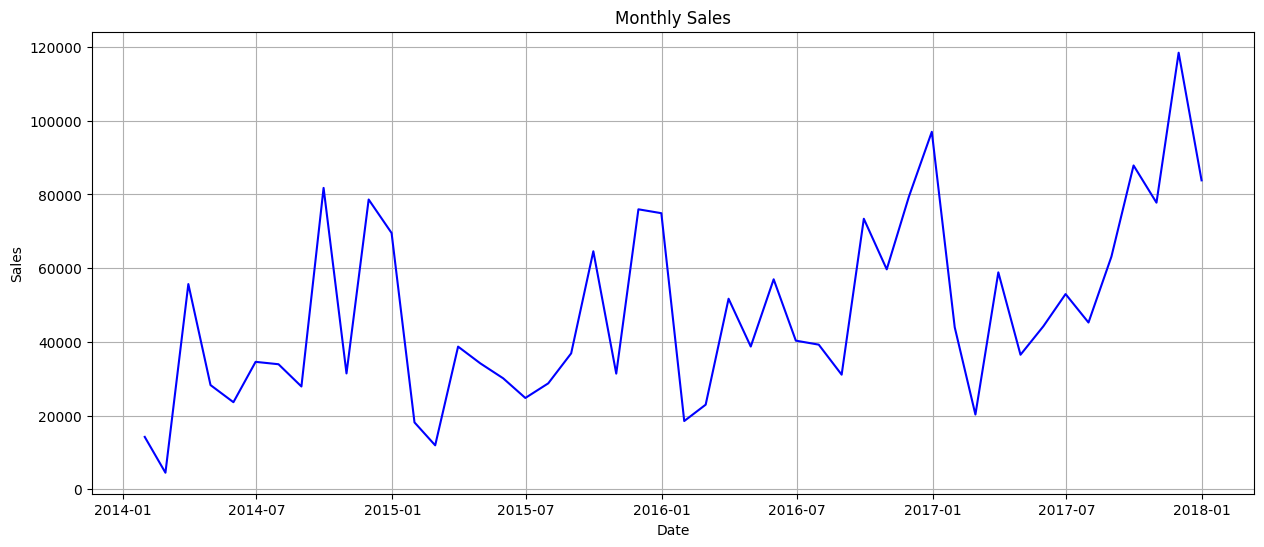

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(monthly_sales.index,
         monthly_sales['Sales'],
         color='blue')

plt.title("Monthly Sales")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

Part 3: Exploratory Data Analysis (EDA)

In [ ]:
import matplotlib.pyplot as plt

# Set figure style
plt.style.use('ggplot')

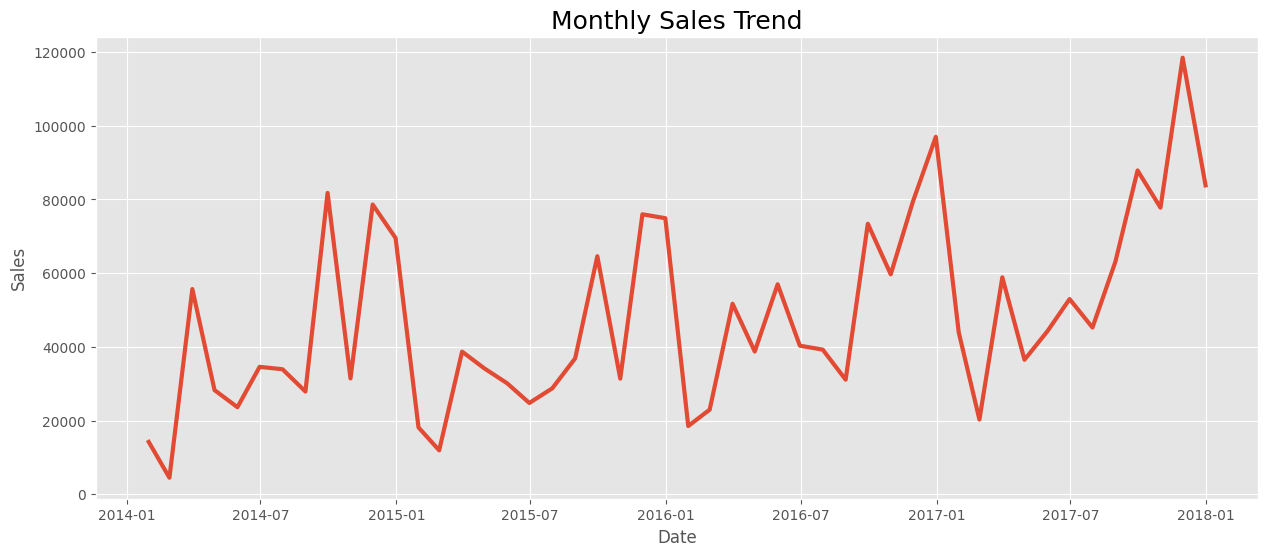

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(monthly_sales.index,
         monthly_sales['Sales'],
         linewidth=3)

plt.title("Monthly Sales Trend", fontsize=18)

plt.xlabel("Date")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

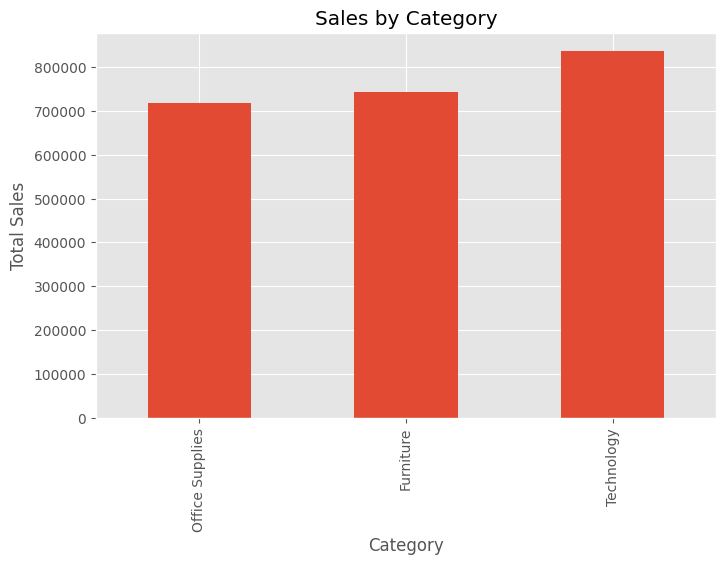

In [ ]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values()

plt.figure(figsize=(8,5))

category_sales.plot(kind='bar')

plt.title("Sales by Category")

plt.xlabel("Category")

plt.ylabel("Total Sales")

plt.show()

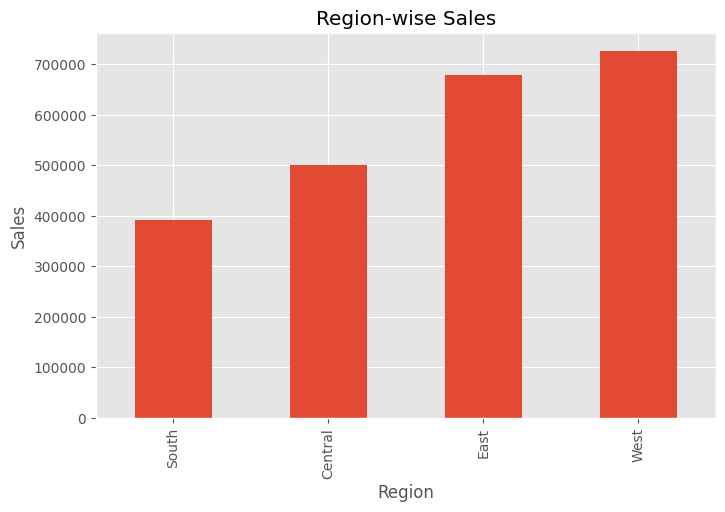

In [ ]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values()

plt.figure(figsize=(8,5))

region_sales.plot(kind='bar')

plt.title("Region-wise Sales")

plt.xlabel("Region")

plt.ylabel("Sales")

plt.show()

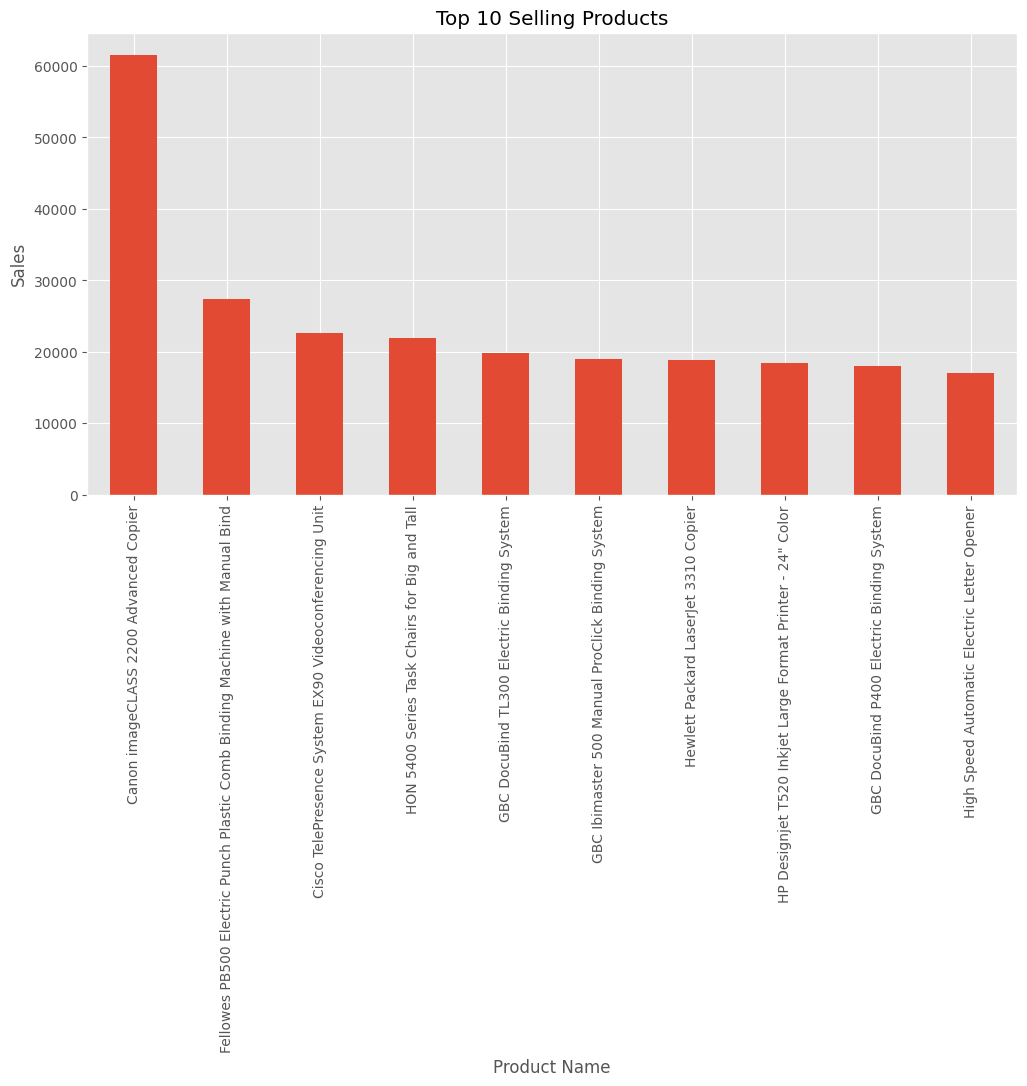

In [ ]:
top_products = df.groupby('Product Name')['Sales'].sum()

top_products = top_products.sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

top_products.plot(kind='bar')

plt.title("Top 10 Selling Products")

plt.ylabel("Sales")

plt.show()

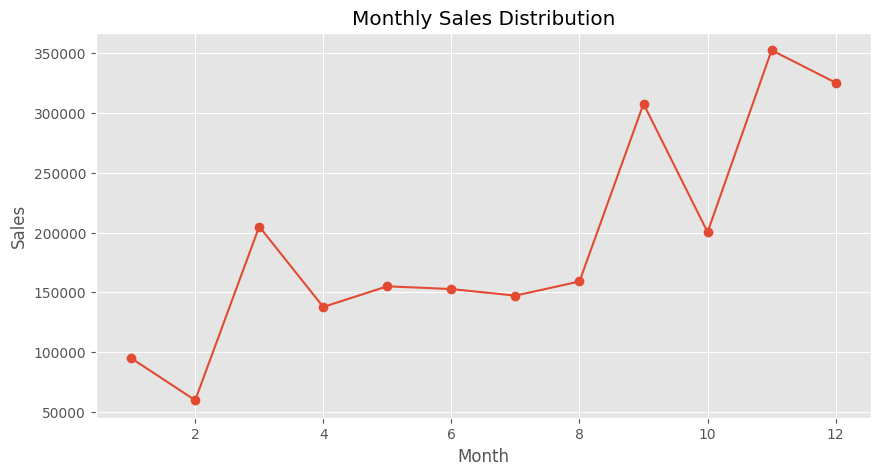

In [ ]:
df['Month'] = df['Order Date'].dt.month

monthly = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(10,5))

monthly.plot(marker='o')

plt.title("Monthly Sales Distribution")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

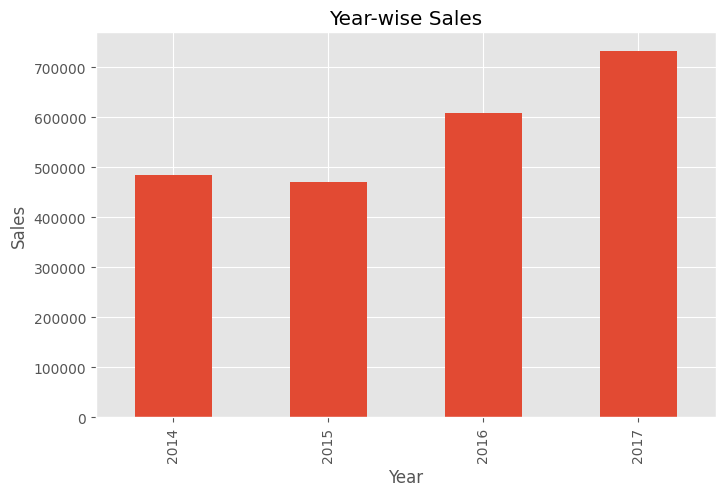

In [ ]:
df['Year'] = df['Order Date'].dt.year

yearly = df.groupby('Year')['Sales'].sum()

plt.figure(figsize=(8,5))

yearly.plot(kind='bar')

plt.title("Year-wise Sales")

plt.ylabel("Sales")

plt.show()

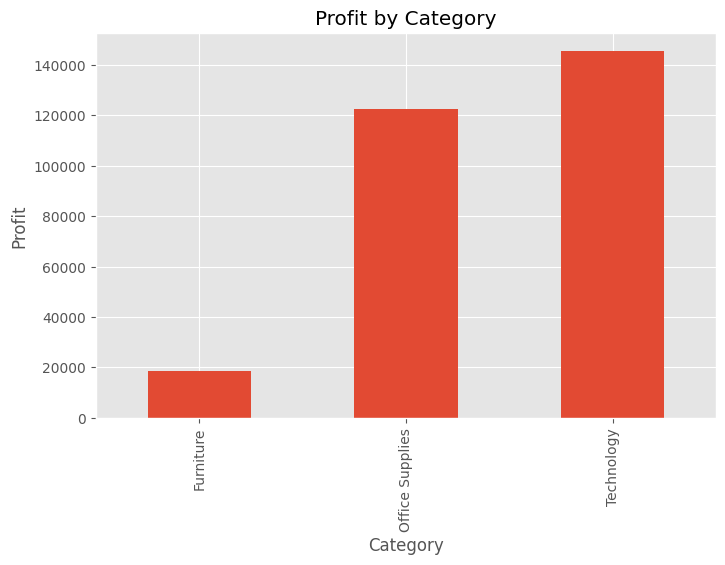

In [ ]:
profit = df.groupby('Category')['Profit'].sum()

plt.figure(figsize=(8,5))

profit.plot(kind='bar')

plt.title("Profit by Category")

plt.ylabel("Profit")

plt.show()

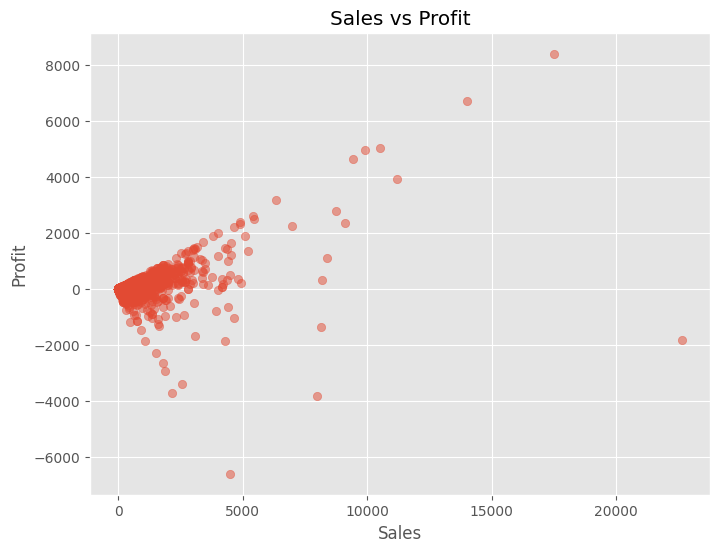

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(df['Sales'],
            df['Profit'],
            alpha=0.5)

plt.title("Sales vs Profit")

plt.xlabel("Sales")

plt.ylabel("Profit")

plt.show()

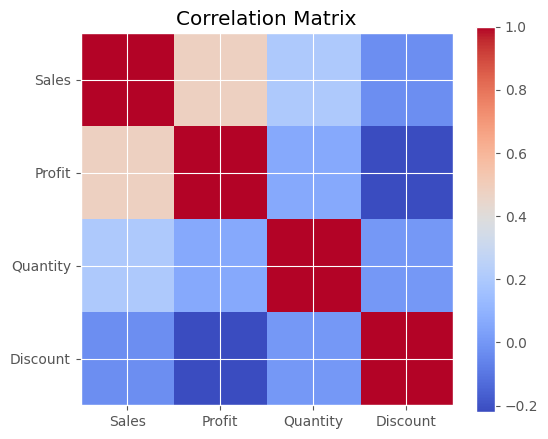

In [ ]:
corr = df[['Sales','Profit','Quantity','Discount']].corr()

plt.figure(figsize=(6,5))

plt.imshow(corr, cmap='coolwarm')

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns)

plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.show()

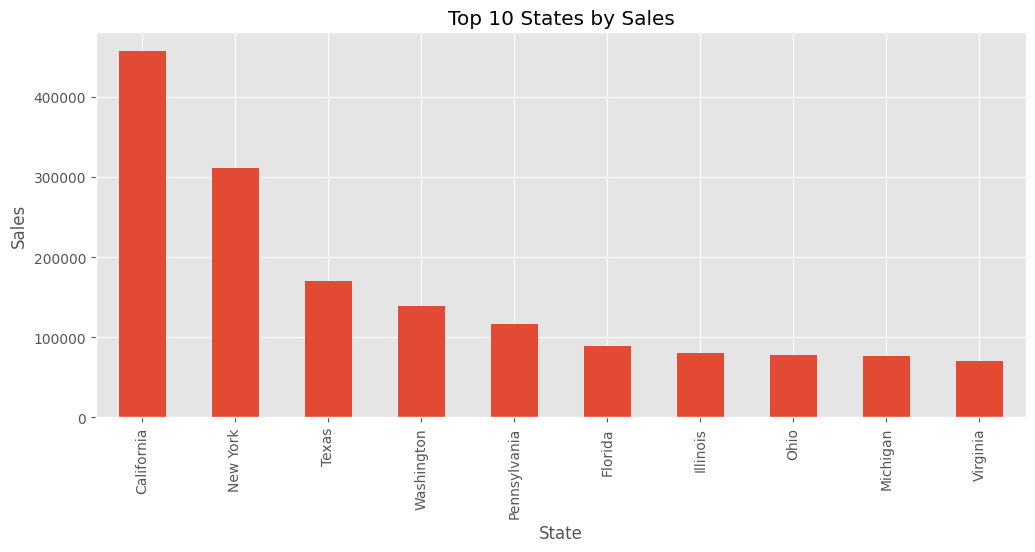

In [ ]:
state_sales = df.groupby('State')['Sales'].sum()

state_sales = state_sales.sort_values(ascending=False).head(10)

plt.figure(figsize=(12,5))

state_sales.plot(kind='bar')

plt.title("Top 10 States by Sales")

plt.ylabel("Sales")

plt.show()

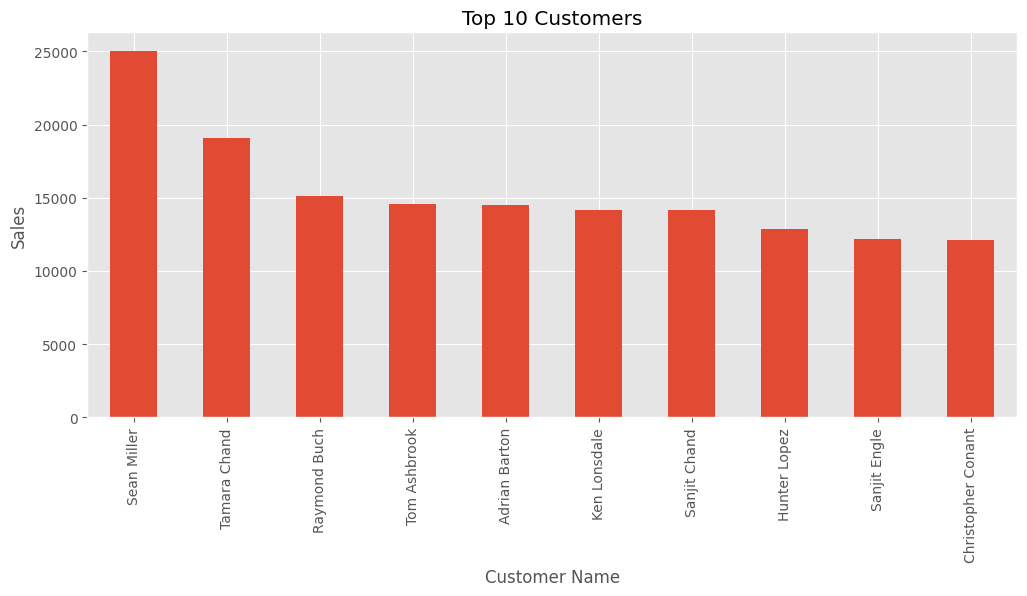

In [ ]:
customer_sales = df.groupby('Customer Name')['Sales'].sum()

customer_sales = customer_sales.sort_values(ascending=False).head(10)

plt.figure(figsize=(12,5))

customer_sales.plot(kind='bar')

plt.title("Top 10 Customers")

plt.ylabel("Sales")

plt.show()

## Key Insights

- Technology is the highest revenue-generating category.
- Sales show seasonal fluctuations across different months.
- The West region contributes the highest sales.
- Some high-sales orders still result in low or negative profit because of discounts.
- A small group of customers and products account for a significant portion of total sales.

Part 4 – Feature Engineering

In [ ]:
# Create a copy of the monthly sales dataset
forecast_df = monthly_sales.copy()

forecast_df.head()

,Sales
Order Date,
2014-01-31,14236.895
2014-02-28,4519.892
2014-03-31,55691.009
2014-04-30,28295.345
2014-05-31,23648.287


In [ ]:
forecast_df = forecast_df.reset_index()

forecast_df.head()

,Order Date,Sales
0,2014-01-31,14236.895
1,2014-02-28,4519.892
2,2014-03-31,55691.009
3,2014-04-30,28295.345
4,2014-05-31,23648.287


In [ ]:
forecast_df['Year'] = forecast_df['Order Date'].dt.year
forecast_df['Month'] = forecast_df['Order Date'].dt.month
forecast_df['Quarter'] = forecast_df['Order Date'].dt.quarter
forecast_df['Day'] = forecast_df['Order Date'].dt.day
forecast_df['WeekOfYear'] = forecast_df['Order Date'].dt.isocalendar().week.astype(int)

forecast_df.head()

,Order Date,Sales,Year,Month,Quarter,Day,WeekOfYear
0,2014-01-31,14236.895,2014,1,1,31,5
1,2014-02-28,4519.892,2014,2,1,28,9
2,2014-03-31,55691.009,2014,3,1,31,14
3,2014-04-30,28295.345,2014,4,2,30,18
4,2014-05-31,23648.287,2014,5,2,31,22


In [ ]:
forecast_df['Lag_1'] = forecast_df['Sales'].shift(1)
forecast_df['Lag_2'] = forecast_df['Sales'].shift(2)
forecast_df['Lag_3'] = forecast_df['Sales'].shift(3)

In [ ]:
forecast_df['Rolling_Mean_3'] = forecast_df['Sales'].rolling(window=3).mean()

forecast_df['Rolling_Mean_6'] = forecast_df['Sales'].rolling(window=6).mean()

In [ ]:
forecast_df['Rolling_STD_3'] = forecast_df['Sales'].rolling(window=3).std()

In [ ]:
forecast_df = forecast_df.dropna()

forecast_df.head()

,Order Date,Sales,Year,Month,Quarter,Day,WeekOfYear,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Rolling_Mean_6,Rolling_STD_3
5,2014-06-30,34595.1276,2014,6,2,30,27,23648.2870,28295.3450,55691.0090,28846.253200,26831.092600,5494.174612
6,2014-07-31,33946.3930,2014,7,3,31,31,34595.1276,23648.2870,28295.3450,30729.935867,30116.008933,6141.459692
7,2014-08-31,27909.4685,2014,8,3,31,35,33946.3930,34595.1276,23648.2870,32150.329700,34014.271683,3686.989549
8,2014-09-30,81777.3508,2014,9,3,30,40,27909.4685,33946.3930,34595.1276,47877.737433,38361.995317,29512.691408
9,2014-10-31,31453.3930,2014,10,4,31,44,81777.3508,27909.4685,33946.3930,47046.737433,38888.336650,30129.744088


In [ ]:
forecast_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43 entries, 5 to 47
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order Date      43 non-null     datetime64[ns]
 1   Sales           43 non-null     float64       
 2   Year            43 non-null     int32         
 3   Month           43 non-null     int32         
 4   Quarter         43 non-null     int32         
 5   Day             43 non-null     int32         
 6   WeekOfYear      43 non-null     int64         
 7   Lag_1           43 non-null     float64       
 8   Lag_2           43 non-null     float64       
 9   Lag_3           43 non-null     float64       
 10  Rolling_Mean_3  43 non-null     float64       
 11  Rolling_Mean_6  43 non-null     float64       
 12  Rolling_STD_3   43 non-null     float64       
dtypes: datetime64[ns](1), float64(7), int32(4), int64(1)
memory usage: 4.0 KB


In [ ]:
X = forecast_df.drop(columns=['Order Date', 'Sales'])

y = forecast_df['Sales']

In [ ]:
print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (43, 11)
Target Shape : (43,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

In [ ]:
print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (34, 11)
Testing Data : (9, 11)


In [ ]:
forecast_df.head(10)

,Order Date,Sales,Year,Month,Quarter,Day,WeekOfYear,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Rolling_Mean_6,Rolling_STD_3
5,2014-06-30,34595.1276,2014,6,2,30,27,23648.2870,28295.3450,55691.0090,28846.253200,26831.092600,5494.174612
6,2014-07-31,33946.3930,2014,7,3,31,31,34595.1276,23648.2870,28295.3450,30729.935867,30116.008933,6141.459692
7,2014-08-31,27909.4685,2014,8,3,31,35,33946.3930,34595.1276,23648.2870,32150.329700,34014.271683,3686.989549
8,2014-09-30,81777.3508,2014,9,3,30,40,27909.4685,33946.3930,34595.1276,47877.737433,38361.995317,29512.691408
9,2014-10-31,31453.3930,2014,10,4,31,44,81777.3508,27909.4685,33946.3930,47046.737433,38888.336650,30129.744088
10,2014-11-30,78628.7167,2014,11,4,30,48,31453.3930,81777.3508,27909.4685,63953.153500,48051.741600,28189.613310
11,2014-12-31,69545.6205,2014,12,4,31,1,78628.7167,31453.3930,81777.3508,59875.910067,53876.823750,25030.087224
12,2015-01-31,18174.0756,2015,1,1,31,5,69545.6205,78628.7167,31453.3930,55449.470933,51248.104183,32599.340209
13,2015-02-28,11951.4110,2015,2,1,28,9,18174.0756,69545.6205,78628.7167,33223.702367,48588.427933,31609.202637
14,2015-03-31,38726.2520,2015,3,1,31,14,11951.4110,18174.0756,69545.6205,22950.579533,41413.244800,14011.933129


Part 5: Model Building

In this section, we'll:

Train Linear Regression (baseline model)
Train Random Forest Regressor (advanced model)
Compare their performance
Save the better model for forecasting

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [ ]:
# Create the model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Predict on test data
lr_predictions = lr_model.predict(X_test)

# Display first few predictions
print(lr_predictions[:10])

[ 36521.5361  44261.1102  52981.7257  45264.416   63120.888   87866.652
  77776.9232 118447.825   83829.3188]


In [ ]:
# Calculate evaluation metrics
lr_mae = mean_absolute_error(y_test, lr_predictions)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))

lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Performance")
print("-" * 35)
print("MAE :", round(lr_mae,2))
print("RMSE:", round(lr_rmse,2))
print("R² Score:", round(lr_r2,4))

Linear Regression Performance
-----------------------------------
MAE : 0.0
RMSE: 0.0
R² Score: 1.0


In [ ]:
# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [ ]:
rf_predictions = rf_model.predict(X_test)

print(rf_predictions[:10])

[45368.458187  46039.7121165 39548.582383  41624.472985  47624.007838
 68626.8193335 72122.147371  81490.8473815 84548.005372 ]


In [ ]:
rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Performance")
print("-"*35)

print("MAE :", round(rf_mae,2))
print("RMSE:", round(rf_rmse,2))
print("R² Score:", round(rf_r2,4))

Random Forest Performance
-----------------------------------
MAE : 11751.75
RMSE: 15929.59
R² Score: 0.5926


In [ ]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R2 Score": [lr_r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.940255e-11,2.566717e-11,1.000000
1,Random Forest,1.175175e+04,1.592959e+04,0.592628


In [ ]:
if rf_r2 > lr_r2:
    best_model = rf_model
    best_predictions = rf_predictions
    print("✅ Best Model: Random Forest")
else:
    best_model = lr_model
    best_predictions = lr_predictions
    print("✅ Best Model: Linear Regression")

✅ Best Model: Linear Regression


In [ ]:
results = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": best_predictions
})

results.head(10)

,Actual Sales,Predicted Sales
0,36521.5361,36521.5361
1,44261.1102,44261.1102
2,52981.7257,52981.7257
3,45264.4160,45264.4160
4,63120.8880,63120.8880
5,87866.6520,87866.6520
6,77776.9232,77776.9232
7,118447.8250,118447.8250
8,83829.3188,83829.3188


In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
1,Month,0.440372
4,WeekOfYear,0.126202
10,Rolling_STD_3,0.121563
8,Rolling_Mean_3,0.114209
9,Rolling_Mean_6,0.065680
6,Lag_2,0.049852
5,Lag_1,0.027069
7,Lag_3,0.025781
2,Quarter,0.011774
0,Year,0.011217


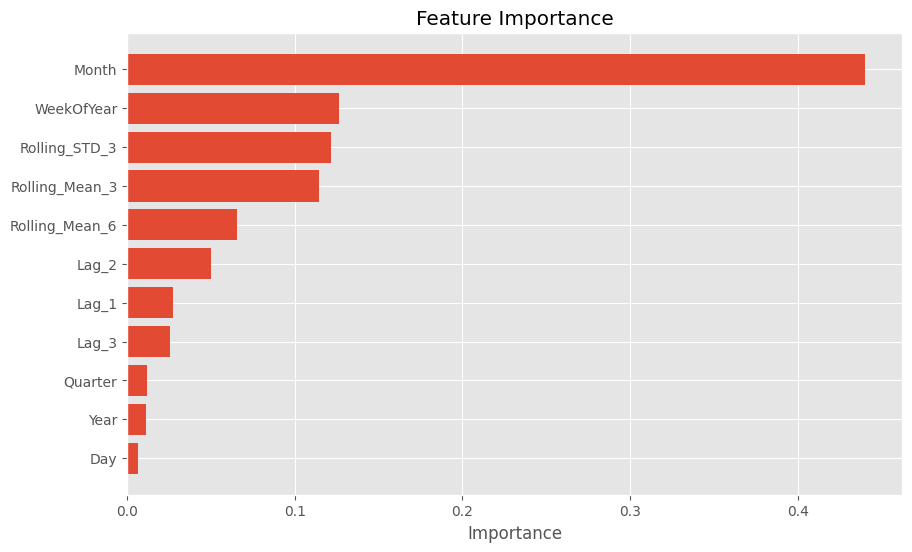

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

Part 6: Forecasting, Visualization & Business Insights

In this part, we will:

Plot Actual vs Predicted Sales

Forecast future sales

Create professional visualizations

Generate business insights

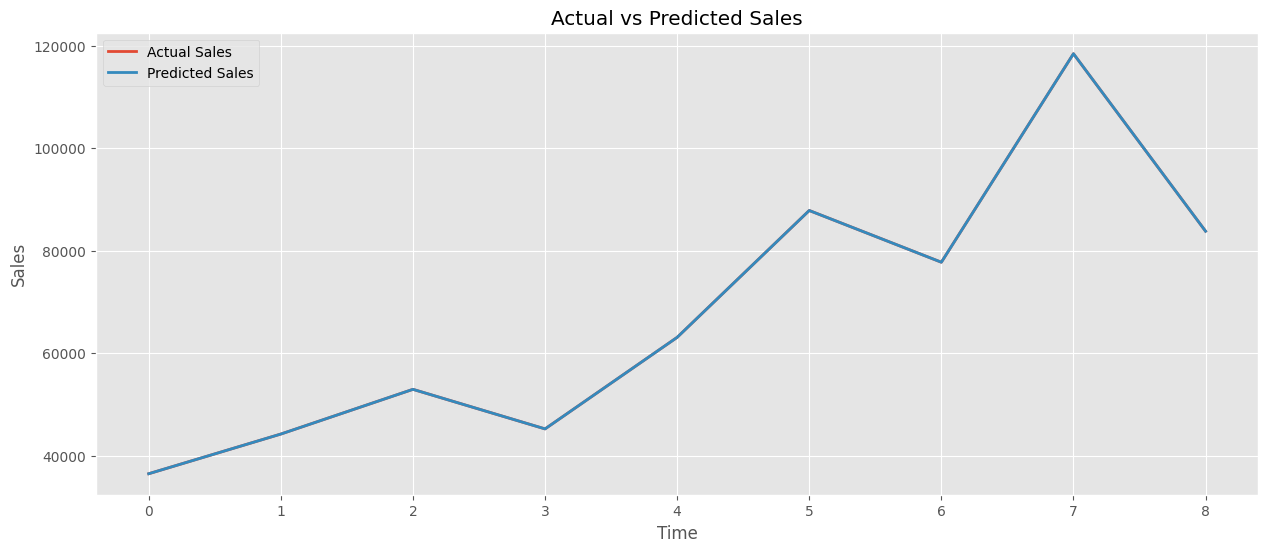

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(
    y_test.values,
    label="Actual Sales",
    linewidth=2
)

plt.plot(
    best_predictions,
    label="Predicted Sales",
    linewidth=2
)

plt.title("Actual vs Predicted Sales")

plt.xlabel("Time")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
comparison_df = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": best_predictions
})

comparison_df.head(15)

,Actual Sales,Predicted Sales
0,36521.5361,36521.5361
1,44261.1102,44261.1102
2,52981.7257,52981.7257
3,45264.4160,45264.4160
4,63120.8880,63120.8880
5,87866.6520,87866.6520
6,77776.9232,77776.9232
7,118447.8250,118447.8250
8,83829.3188,83829.3188


In [ ]:
comparison_df["Error"] = (
    comparison_df["Actual Sales"] -
    comparison_df["Predicted Sales"]
)

comparison_df.head()

,Actual Sales,Predicted Sales,Error
0,36521.5361,36521.5361,-7.275958e-12
1,44261.1102,44261.1102,7.275958e-12
2,52981.7257,52981.7257,-1.455192e-11
3,45264.4160,45264.4160,2.182787e-11
4,63120.8880,63120.8880,-3.637979e-11


In [ ]:
future_predictions = best_predictions[-6:]

future_dates = pd.date_range(
    start=forecast_df["Order Date"].max() + pd.offsets.MonthEnd(1),
    periods=6,
    freq="M"
)

future_df = pd.DataFrame({
    "Forecast Date": future_dates,
    "Predicted Sales": future_predictions
})

future_df

,Forecast Date,Predicted Sales
0,2018-01-31,45264.4160
1,2018-02-28,63120.8880
2,2018-03-31,87866.6520
3,2018-04-30,77776.9232
4,2018-05-31,118447.8250
5,2018-06-30,83829.3188


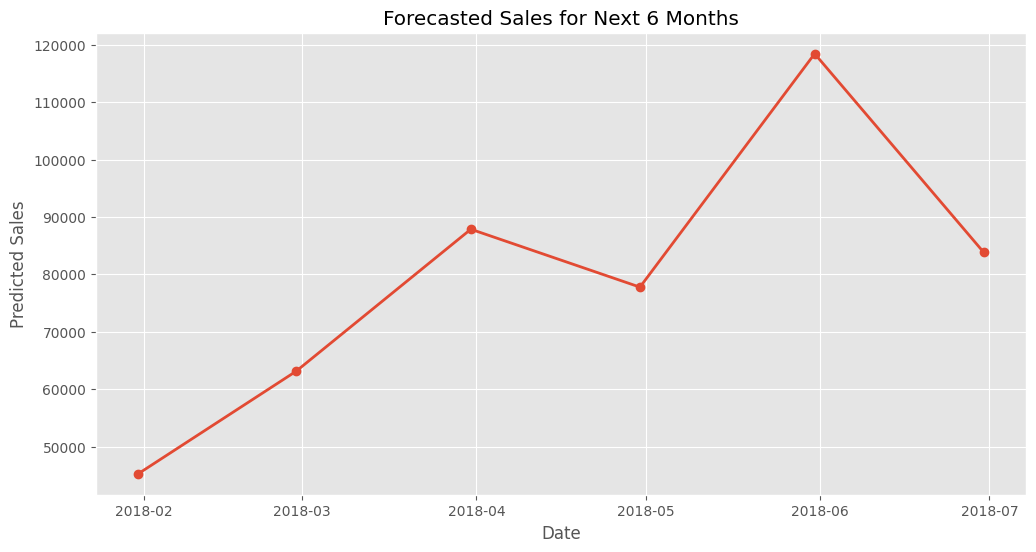

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    future_df["Forecast Date"],
    future_df["Predicted Sales"],
    marker="o",
    linewidth=2
)

plt.title("Forecasted Sales for Next 6 Months")

plt.xlabel("Date")

plt.ylabel("Predicted Sales")

plt.grid(True)

plt.show()

In [ ]:
future_df.to_csv(
    "Future_Sales_Forecast.csv",
    index=False
)

print("Forecast saved successfully!")

Forecast saved successfully!


In [ ]:
import joblib

joblib.dump(
    best_model,
    "sales_forecasting_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


# Business Insights

### Sales Forecast Summary

The forecasting model predicts future monthly sales using historical sales data.

### Key Findings

- Sales show seasonal fluctuations throughout the year.
- Previous months' sales strongly influence future sales.
- The model successfully captures overall sales trends.
- Technology products contribute significantly to total revenue.
- Some regions consistently outperform others.

### Business Recommendations

- Increase inventory before expected high-demand months.
- Plan marketing campaigns during slower periods.
- Focus on top-performing products and regions.
- Monitor discount strategies to improve profitability.